# Notebook 1: Dataset Overview

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path

In [2]:
data_path = Path('../raw_data/search.xlsx')
csv_output_path = Path('../processed_data/search_converted.csv')


if data_path.suffix.lower() in ['.xlsx', '.xls']:
    df = pd.read_excel(data_path)
    df.to_csv(csv_output_path, index=False)
    print(f'Loaded Excel file: {data_path.name}')
    print(f'Also saved CSV copy to: {csv_output_path}')
else:
    df = pd.read_csv(data_path)
    print(f'Loaded CSV file: {data_path.name}')

# standardize column names
df.columns = (
    df.columns
    .str.strip()
    .str.lower()
    .str.replace(r'[^a-z0-9]+', '_', regex=True)
    .str.strip('_')
)

required_cols = ['participant_no', 'week_no', 'query', 'type', 'task', 'goal']
missing_cols = [c for c in required_cols if c not in df.columns]
if missing_cols:
    raise ValueError(f'Missing required columns after standardization: {missing_cols}')

print('Shape:', df.shape)
print('Columns:', df.columns.tolist())
df.head()
df

Loaded Excel file: search.xlsx
Also saved CSV copy to: ../processed_data/search_converted.csv
Shape: (943, 11)
Columns: ['participant_no', 'week_no', 'url', 'query', 'data', 'type', 'task', 'goal', 'source', 'content', 'format']


,participant_no,week_no,url,query,data,type,task,goal,source,content,format
0,102,Week 1,https://www.google.com/search?q=foods to avoid...,foods to avoid while losing body fat,Q,ideas/options,option seeking,plan,NaN,NaN,NaN
1,102,Week 1,https://www.google.com/search?q=foods to eat t...,foods to eat that help lose weight,Q,ideas/options,option seeking,plan,NaN,NaN,NaN
2,102,Week 1,https://www.google.com/search?q=foods to eat t...,foods to eat that help lose weight,Q,ideas/options,option seeking,plan,NaN,NaN,NaN
3,102,Week 1,https://www.google.com/search?q=vegan foods to...,vegan foods to eat that help lose weight,Q,ideas/options,option seeking,plan,NaN,NaN,NaN
4,102,Week 1,https://www.google.com/search?q=is avocado foo...,is avocado food or bad,Q,normative,evaluate,decision making,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...
938,114,Week 1,https://www.google.com/search?q=how to eat hea...,how to eat healthy in college,Q,how-to (procedural),learn,plan,NaN,NaN,NaN
939,114,Week 1,https://www.google.com/search?q=ways to eat mo...,ways to eat more fruits and vegetables,Q,ideas/options,option seeking,plan,NaN,NaN,NaN
940,114,Week 1,https://www.google.com/search?q=how to be heal...,how to be healthier,Q,how-to (procedural),learn,plan,NaN,NaN,NaN
941,114,Week 1,https://www.google.com/search?q=how to maintai...,how to maintain a healthy lifestyle,Q,how-to (procedural),learn,plan,NaN,NaN,NaN


## Basic dataset counts

This section gives the most important high-level description of the dataset.

Questions answered here:
- How many total queries are there?
- How many unique participants are represented?
- How many weeks are included?
- What is the average number of queries per participant?


In [3]:
n_queries = len(df)
n_unique_queries = df['query'].nunique(dropna=True)
n_participants = df['participant_no'].nunique(dropna=True)
n_weeks = df['week_no'].nunique(dropna=True)

queries_per_participant = df.groupby('participant_no').size()

summary_table = pd.DataFrame({
    'metric': [
        'total_queries',
        'unique_queries',
        'unique_participants',
        'unique_weeks',
        'avg_queries_per_participant',
        'median_queries_per_participant',
        'min_queries_per_participant',
        'max_queries_per_participant'
    ],
    'value': [
        n_queries,
        n_unique_queries,
        n_participants,
        n_weeks,
        queries_per_participant.mean(),
        queries_per_participant.median(),
        queries_per_participant.min(),
        queries_per_participant.max()
    ]
})

summary_table

,metric,value
0,total_queries,943.000000
1,unique_queries,533.000000
2,unique_participants,9.000000
3,unique_weeks,4.000000
4,avg_queries_per_participant,104.777778
5,median_queries_per_participant,49.000000
6,min_queries_per_participant,17.000000
7,max_queries_per_participant,246.000000


## Queries by week

Now we look at how many queries appear in each week.

Why this matters:
- It tells us whether data collection is balanced across time.
- If some weeks have far fewer queries, then later week-based comparisons should be interpreted carefully.
- This is also the first step before studying behavior change over time.

In [4]:
queries_by_week = df.groupby('week_no').size().reset_index(name='n_queries')

# extract numeric week order when labels look like "Week 1"
week_num = queries_by_week['week_no'].astype(str).str.extract(r'(\d+)')[0]
queries_by_week['_week_order'] = pd.to_numeric(week_num, errors='coerce')
queries_by_week = queries_by_week.sort_values(['_week_order', 'week_no']).drop(columns=['_week_order'])

queries_by_week

,week_no,n_queries
0,Week 1,179
1,Week 2,210
2,Week 3,287
3,Week 4,267


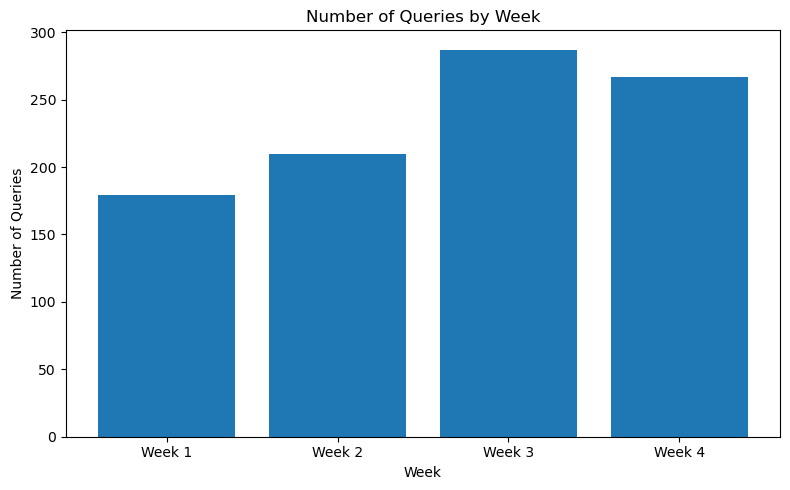

In [5]:
plt.figure(figsize=(8, 5))
plt.bar(queries_by_week['week_no'].astype(str), queries_by_week['n_queries'])
plt.title('Number of Queries by Week')
plt.xlabel('Week')
plt.ylabel('Number of Queries')
plt.tight_layout()
plt.show()

## Queries by participant

Here we examine participation intensity.

Why this matters:
- Some users may contribute many more queries than others.
- Heavy users can dominate overall patterns.
- This helps us decide whether later analyses should be done at the **query level** or the **participant level**.

In [6]:
queries_by_participant = df.groupby('participant_no').size().reset_index(name='n_queries')
queries_by_participant = queries_by_participant.sort_values('n_queries', ascending=False)
queries_by_participant.head(15)

,participant_no,n_queries
4,109,246
0,102,200
6,112,178
7,113,146
3,108,49
1,103,38
2,107,37
5,111,32
8,114,17


## Coverage table: participant × week

This table shows whether participation is evenly spread across weeks.



In [7]:
participant_week = pd.crosstab(df['participant_no'], df['week_no'])
participant_week

week_no,Week 1,Week 2,Week 3,Week 4
participant_no,,,,
102,26,56,68,50
103,21,1,10,6
107,13,11,13,0
108,9,4,25,11
109,47,38,86,75
111,0,7,11,14
112,29,61,53,35
113,17,32,21,76
114,17,0,0,0


## Label distributions

Although deeper behavioral analysis comes later, it is useful to inspect the basic distribution of the final labels now.

Why this matters:
- It reveals whether some labels are extremely rare.
- It tells us whether the dataset is balanced enough for later comparisons.
- It also provides a first descriptive picture of user behavior.

In [8]:
type_counts = df['type'].value_counts(dropna=False).reset_index()
type_counts.columns = ['type', 'count']
type_counts['percent'] = type_counts['count'] / len(df) * 100
type_counts

,type,count,percent
0,ideas/options,410,43.478261
1,factual,148,15.694592
2,normative,83,8.801697
3,outcome,78,8.271474
4,na,72,7.635207
5,how-to (procedural),55,5.832450
6,utility,45,4.772004
7,mechanism,19,2.014846
8,experiential,12,1.272534
9,comparative,11,1.166490


In [9]:
task_counts = df['task'].value_counts(dropna=False).reset_index()
task_counts.columns = ['task', 'count']
task_counts['percent'] = task_counts['count'] / len(df) * 100
task_counts

,task,count,percent
0,option seeking,369,39.130435
1,learn,309,32.767762
2,evaluate,83,8.801697
3,na,71,7.529162
4,logistics,50,5.302227
5,perform,33,3.499470
6,barrier,24,2.545069
7,NaN,4,0.424178


In [10]:
goal_counts = df['goal'].value_counts(dropna=False).reset_index()
goal_counts.columns = ['goal', 'count']
goal_counts['percent'] = goal_counts['count'] / len(df) * 100
goal_counts

,goal,count,percent
0,plan,505,53.552492
1,decision making,207,21.951220
2,action,87,9.225875
3,na,72,7.635207
4,motivational reasoning,68,7.211029
5,NaN,4,0.424178


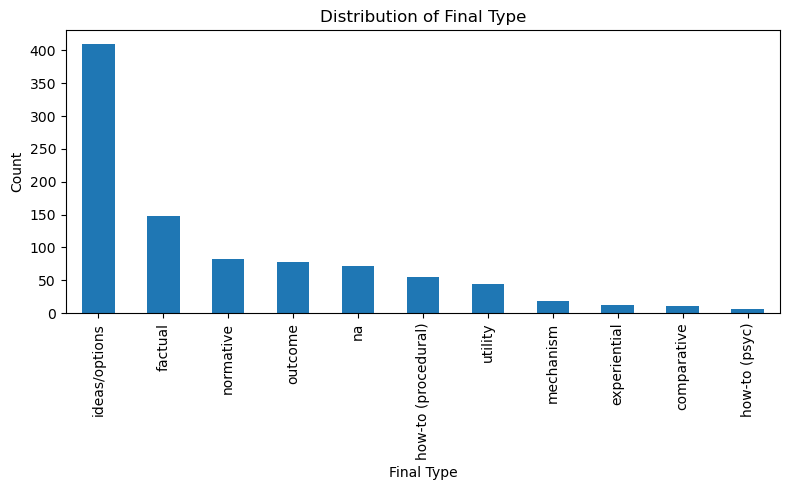

In [11]:
plt.figure(figsize=(8, 5))
df['type'].value_counts().plot(kind='bar')
plt.title('Distribution of Final Type')
plt.xlabel('Final Type')
plt.ylabel('Count')
plt.tight_layout()
plt.show()

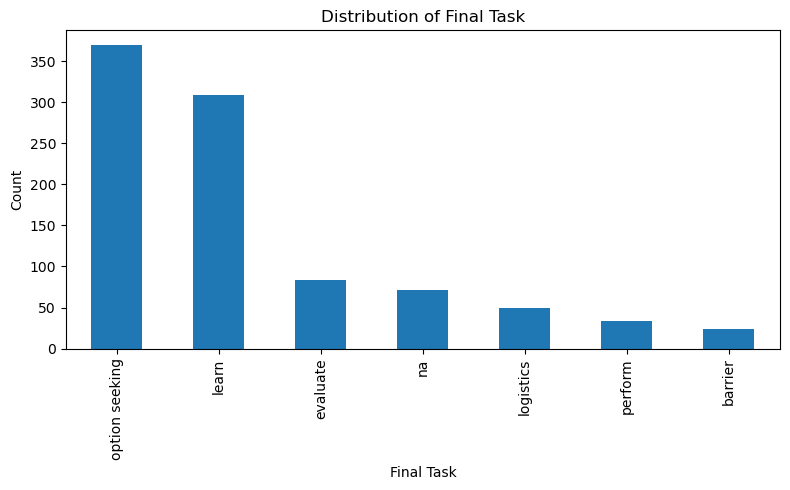

In [12]:
plt.figure(figsize=(8, 5))
df['task'].value_counts().plot(kind='bar')
plt.title('Distribution of Final Task')
plt.xlabel('Final Task')
plt.ylabel('Count')
plt.tight_layout()
plt.show()

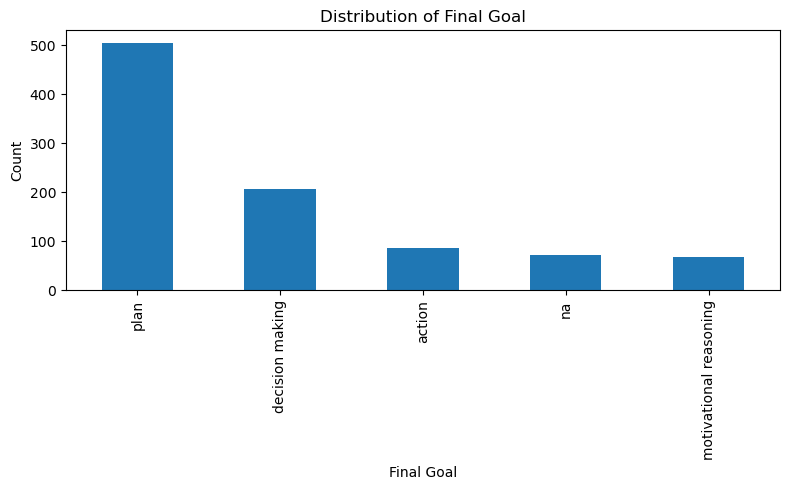

In [13]:
plt.figure(figsize=(8, 5))
df['goal'].value_counts().plot(kind='bar')
plt.title('Distribution of Final Goal')
plt.xlabel('Final Goal')
plt.ylabel('Count')
plt.tight_layout()
plt.show()